## Black Scholes Pricer with Greeks

In [1]:
import numpy as np
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type='call'):
    """
    S     : current stock price
    K     : strike price
    T     : time to expiry (in years)
    r     : risk-free rate (e.g. 0.05 for 5%)
    sigma : volatility (e.g. 0.2 for 20%)
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return price

def greeks(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta = norm.cdf(d1) if option_type == 'call' else -norm.cdf(-d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T) / 100          # per 1 vol point
    theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
             - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365  # per day

    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta}

# Test it
print(black_scholes(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type='call'))
print(greeks(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type='call'))

10.450583572185565
{'delta': np.float64(0.6368306511756191), 'gamma': np.float64(0.018762017345846895), 'vega': np.float64(0.3752403469169379), 'theta': np.float64(-0.01757267820941972)}


## Monte Carlo Engine

### 1. Single Price Path (random)

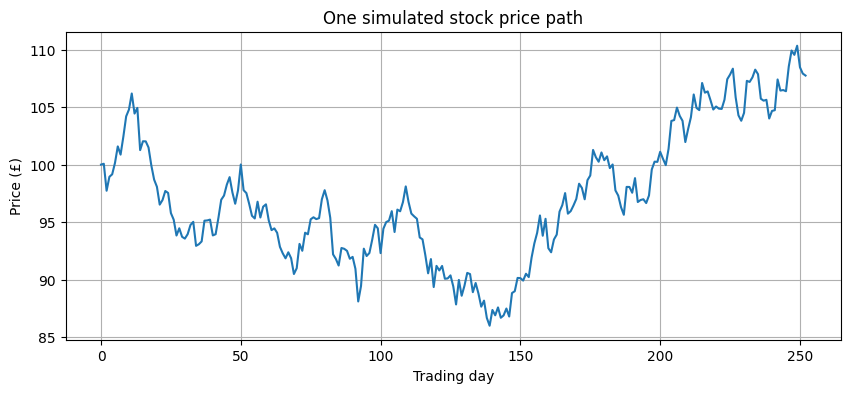

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
S = 100       # starting price
T = 1         # 1 year
r = 0.05      # risk-free rate
sigma = 0.2   # volatility
n_steps = 252 # one step per trading day

dt = T / n_steps
prices = [S]

for _ in range(n_steps):
    shock = np.random.normal(0, 1)
    next_price = prices[-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*shock)
    prices.append(next_price)

plt.figure(figsize=(10, 4))
plt.plot(prices)
plt.title('One simulated stock price path')
plt.xlabel('Trading day')
plt.ylabel('Price (£)')
plt.grid(True)
plt.show()

### 2. Vectorised Operations

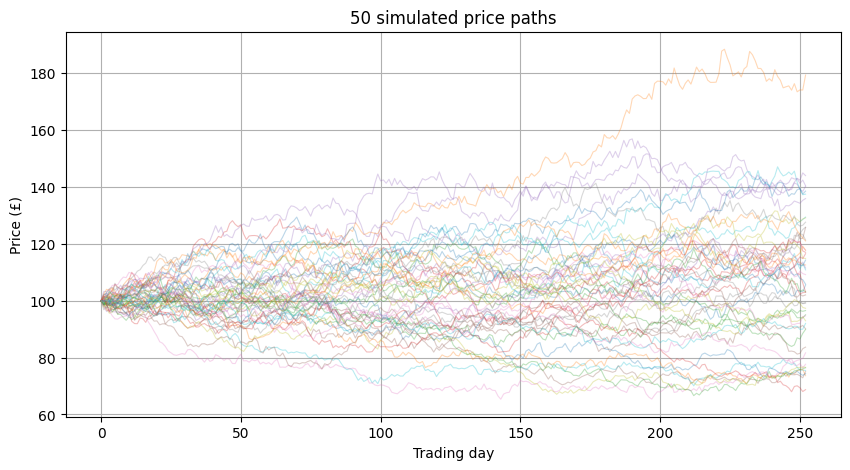

Path matrix shape: (10000, 253)


In [8]:
def simulate_paths(S, T, r, sigma, n_steps=252, n_sims=10000):
    dt = T / n_steps

    # Generate all random shocks at once: shape (n_sims, n_steps)
    shocks = np.random.normal(0, 1, size=(n_sims, n_steps))

    # Daily returns
    daily_returns = np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*shocks)

    # Build price paths: prepend starting price and take cumulative product
    ones = np.ones((n_sims, 1))
    price_paths = S * np.cumprod(np.hstack([ones, daily_returns]), axis=1)

    return price_paths  # shape: (n_sims, n_steps+1)

paths = simulate_paths(S=100, T=1, r=0.05, sigma=0.2)

# Visualise 50 paths
plt.figure(figsize=(10, 5))
plt.plot(paths[:50].T, alpha=0.3, linewidth=0.8)
plt.title('50 simulated price paths')
plt.xlabel('Trading day')
plt.ylabel('Price (£)')
plt.grid(True)
plt.show()

print(f"Path matrix shape: {paths.shape}")  # should be (10000, 253)

### 3. Alternative Paths

In [9]:
def monte_carlo_pricer(S, K, T, r, sigma, option_type='european_call',
                       barrier=None, n_steps=252, n_sims=10000):

    paths = simulate_paths(S, T, r, sigma, n_steps, n_sims)
    final_prices = paths[:, -1]      # price at expiry
    avg_prices   = paths.mean(axis=1) # average price over the path

    if option_type == 'european_call':
        payoffs = np.maximum(final_prices - K, 0)

    elif option_type == 'european_put':
        payoffs = np.maximum(K - final_prices, 0)

    elif option_type == 'asian_call':
        # Payoff based on average price, not final price
        payoffs = np.maximum(avg_prices - K, 0)

    elif option_type == 'barrier_call':
        # Knocked out if price ever hits the barrier
        assert barrier is not None, "Provide a barrier level"
        hit_barrier = paths.max(axis=1) >= barrier
        payoffs = np.where(hit_barrier, 0, np.maximum(final_prices - K, 0))

    # Discount average payoff back to today
    price = np.exp(-r * T) * np.mean(payoffs)
    return price

# Sanity check: MC vs BS should be close for European options
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

bs_price = black_scholes(S, K, T, r, sigma, 'call')
mc_price = monte_carlo_pricer(S, K, T, r, sigma, 'european_call')

print(f"Black-Scholes price:  £{bs_price:.4f}")
print(f"Monte Carlo price:    £{mc_price:.4f}")
print(f"Difference:           £{abs(bs_price-mc_price):.4f}")

# Now price the path-dependent options BS can't handle
asian_price   = monte_carlo_pricer(S, K, T, r, sigma, 'asian_call')
barrier_price = monte_carlo_pricer(S, K, T, r, sigma, 'barrier_call', barrier=120)

print(f"\nAsian call price:     £{asian_price:.4f}")
print(f"Barrier call price    £{barrier_price:.4f}")
print(f"(barrier at £120 — knocked out if stock ever hits £120)")

Black-Scholes price:  £10.4506
Monte Carlo price:    £10.5024
Difference:           £0.0519

Asian call price:     £5.8087
Barrier call price    £1.2928
(barrier at £120 — knocked out if stock ever hits £120)


## Implied Volatility Surface

### 1. Install yfinance + pull data

In [10]:
!pip install yfinance --quiet

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm
from datetime import datetime

# Black-Scholes (copy from Stage 1)
def black_scholes(S, K, T, r, sigma, option_type='call'):
    if T <= 0 or sigma <= 0:
        return 0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

### 2. Pull live SPY Options data

In [13]:
ticker = yf.Ticker("SPY")

# Current spot price
S = ticker.history(period="1d")['Close'].iloc[-1]
r = 0.05  # approximate risk-free rate

print(f"SPY spot price: ${S:.2f}")
print(f"Available expiries: {ticker.options[:6]}")  # show first 6

SPY spot price: $746.74
Available expiries: ('2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-29')


### 3. Implied Volatility across all strikes

In [25]:
def implied_vol(market_price, S, K, T, r, option_type='call'):
    """Invert BS numerically to find the vol that matches the market price."""
    intrinsic = max(S - K, 0) if option_type == 'call' else max(K - S, 0)
    if market_price <= intrinsic + 1e-5:
        return np.nan
    try:
        iv = brentq(
            lambda sigma: black_scholes(S, K, T, r, sigma, option_type) - market_price,
            1e-4, 5.0,
            xtol=1e-6
        )
        return iv
    except:
        return np.nan

# Pick your expiry — change index to select different dates
expiry = ticker.options[11]
T = (datetime.strptime(expiry, "%Y-%m-%d") - datetime.today()).days / 365
print(f"\nUsing expiry: {expiry} ({T*365:.0f} days, T={T:.3f})")

# Pull the options chain
chain  = ticker.option_chain(expiry)
calls  = chain.calls.copy()
puts   = chain.puts.copy()

# Use mid-price (average of bid and ask)
calls['mid'] = (calls['bid'] + calls['ask']) / 2
puts['mid']  = (puts['bid']  + puts['ask'])  / 2

# Filter for liquid strikes only (non-zero bid, reasonable spread)
calls = calls[(calls['bid'] > 0.05) & (calls['strike'].between(S*0.8, S*1.2))]
puts  = puts[ (puts['bid']  > 0.05) & (puts['strike'].between(S*0.8, S*1.2))]

# Calculate implied vols
calls['impl_vol'] = calls.apply(
    lambda row: implied_vol(row['mid'], S, row['strike'], T, r, 'call'), axis=1)
puts['impl_vol'] = puts.apply(
    lambda row: implied_vol(row['mid'], S, row['strike'], T, r, 'put'), axis=1)

calls = calls.dropna(subset=['impl_vol'])
puts  = puts.dropna(subset=['impl_vol'])

print(f"Calls with valid IV: {len(calls)}")
print(f"Puts with valid IV:  {len(puts)}")


Using expiry: 2026-07-31 (40 days, T=0.110)
Calls with valid IV: 188
Puts with valid IV:  162


### 4. Plot Volatility Smile

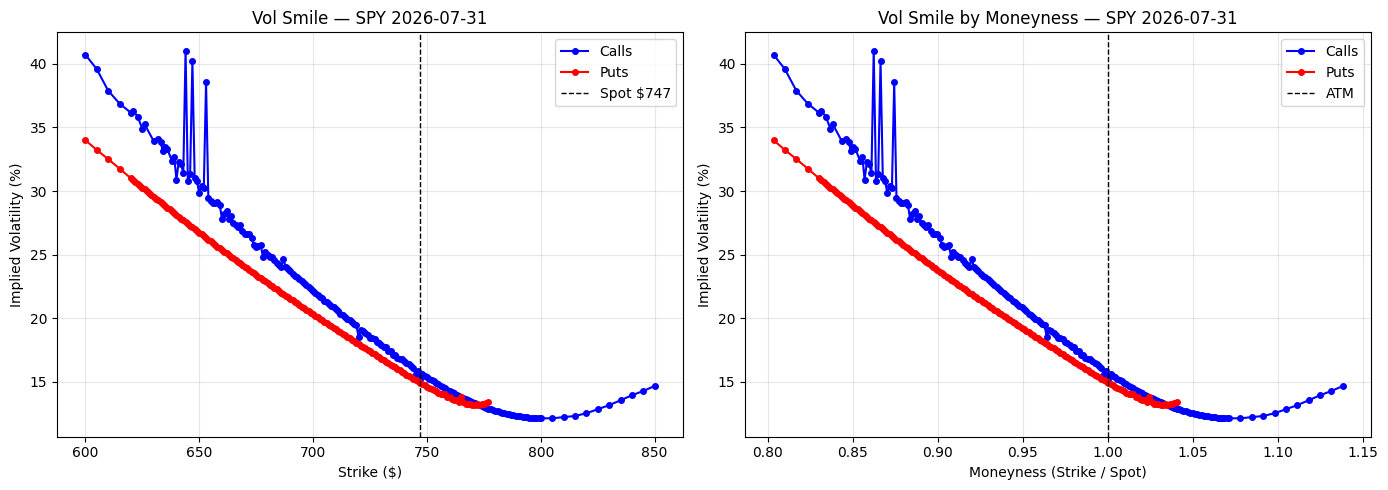


ATM implied vol: ~15.8%


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: IV vs Strike
axes[0].plot(calls['strike'], calls['impl_vol']*100, 'b-o',
             markersize=4, label='Calls', linewidth=1.5)
axes[0].plot(puts['strike'],  puts['impl_vol']*100,  'r-o',
             markersize=4, label='Puts',  linewidth=1.5)
axes[0].axvline(S, color='black', linestyle='--', linewidth=1, label=f'Spot ${S:.0f}')
axes[0].set_xlabel('Strike ($)')
axes[0].set_ylabel('Implied Volatility (%)')
axes[0].set_title(f'Vol Smile — SPY {expiry}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: IV vs Moneyness (more intuitive)
calls['moneyness'] = calls['strike'] / S
puts['moneyness']  = puts['strike']  / S

axes[1].plot(calls['moneyness'], calls['impl_vol']*100, 'b-o',
             markersize=4, label='Calls', linewidth=1.5)
axes[1].plot(puts['moneyness'],  puts['impl_vol']*100,  'r-o',
             markersize=4, label='Puts',  linewidth=1.5)
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1, label='ATM')
axes[1].set_xlabel('Moneyness (Strike / Spot)')
axes[1].set_ylabel('Implied Volatility (%)')
axes[1].set_title(f'Vol Smile by Moneyness — SPY {expiry}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print ATM vol for reference
atm_calls = calls[abs(calls['moneyness'] - 1.0) < 0.02]
if len(atm_calls) > 0:
    print(f"\nATM implied vol: ~{atm_calls['impl_vol'].mean()*100:.1f}%")

### 5. Across multiple expiries

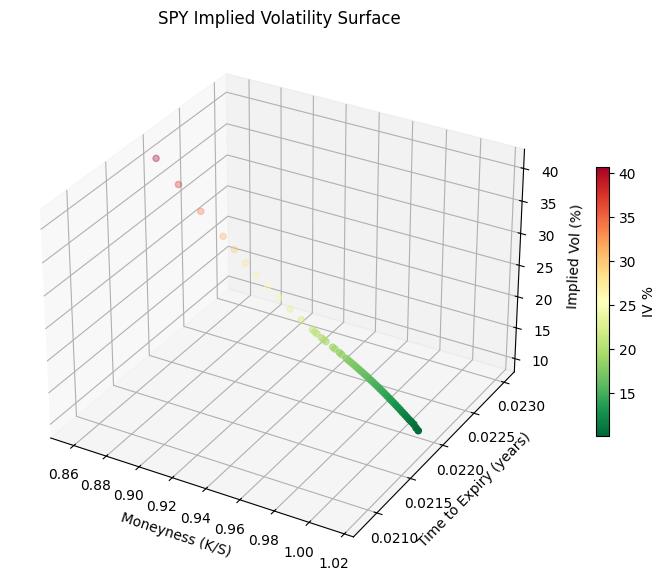

expiry
2026-06-29    18.5%
Name: impl_vol, dtype: object


In [27]:
from mpl_toolkits.mplot3d import Axes3D

surface_data = []

# Loop through first 6 expiries
for expiry in ticker.options[:6]:
    T_exp = (datetime.strptime(expiry, "%Y-%m-%d") - datetime.today()).days / 365
    if T_exp < 0.02:  # skip if less than ~1 week out
        continue

    try:
        chain = ticker.option_chain(expiry)
        puts  = chain.puts.copy()
        puts['mid'] = (puts['bid'] + puts['ask']) / 2
        puts = puts[(puts['bid'] > 0.05) & (puts['strike'].between(S*0.85, S*1.15))]

        puts['impl_vol'] = puts.apply(
            lambda row: implied_vol(row['mid'], S, row['strike'], T_exp, r, 'put'), axis=1)
        puts = puts.dropna(subset=['impl_vol'])
        puts['T'] = T_exp
        puts['expiry'] = expiry
        puts['moneyness'] = puts['strike'] / S
        surface_data.append(puts[['moneyness', 'T', 'impl_vol', 'expiry']])
    except:
        continue

surface_df = pd.concat(surface_data, ignore_index=True)

# 3D surface plot
fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(surface_df['moneyness'],
                     surface_df['T'],
                     surface_df['impl_vol']*100,
                     c=surface_df['impl_vol']*100,
                     cmap='RdYlGn_r',
                     s=20)

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Time to Expiry (years)')
ax.set_zlabel('Implied Vol (%)')
ax.set_title('SPY Implied Volatility Surface')
plt.colorbar(scatter, shrink=0.5, label='IV %')
plt.show()

print(surface_df.groupby('expiry')['impl_vol'].mean().apply(lambda x: f"{x*100:.1f}%"))